In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv('student_scores.csv')

print(df.head())
print(df.columns)

   Hours  Scores
0    1.1      41
1    1.2      40
2    1.4      38
3    1.5      39
4    1.6      36
Index(['Hours', 'Scores'], dtype='str')


In [2]:
X = df[['Hours']]
y = df['Scores']

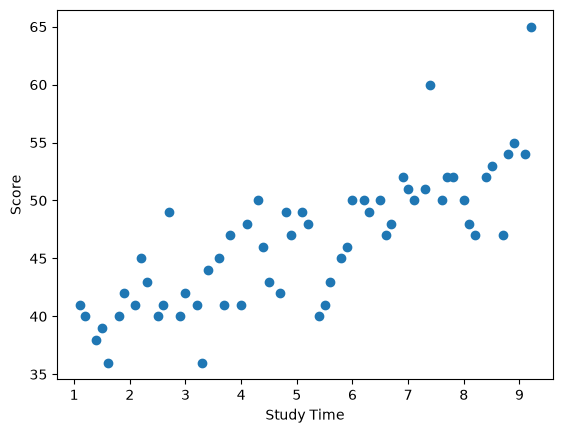

In [3]:
plt.scatter(X, y)
plt.xlabel('Study Time')
plt.ylabel('Score')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

In [5]:
regressor = LinearRegression()

regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.67]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [6]:
a = regressor.intercept_
b = regressor.coef_[0]

print("Estimated model intercept, a:", a)
print("Estimated model slope, b:", b)
print(f"ŷ = {a:.2f} + {b:.2f}x")

Estimated model intercept, a: 37.89028997006413
Estimated model slope, b: 1.6690585851433417
ŷ = 37.89 + 1.67x


In [7]:
y_pred = regressor.predict(X_test)

print(y_pred)

[45.73486532 47.73773562 53.24562895 46.06867704 42.22984229 40.22697199
 47.57082976 53.07872309 48.90607663 44.73343017 40.56078371 42.06293643]


In [8]:
score = r2_score(y_test, y_pred)

print("R-Square:", score)

R-Square: 0.6886702273580021


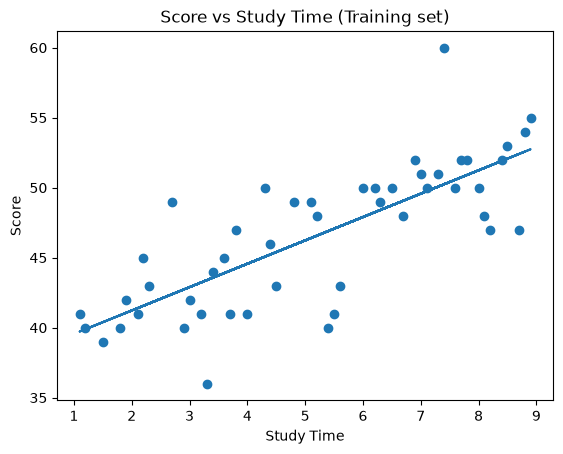

In [9]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train))

plt.title('Score vs Study Time (Training set)')
plt.xlabel('Study Time')
plt.ylabel('Score')

plt.show()

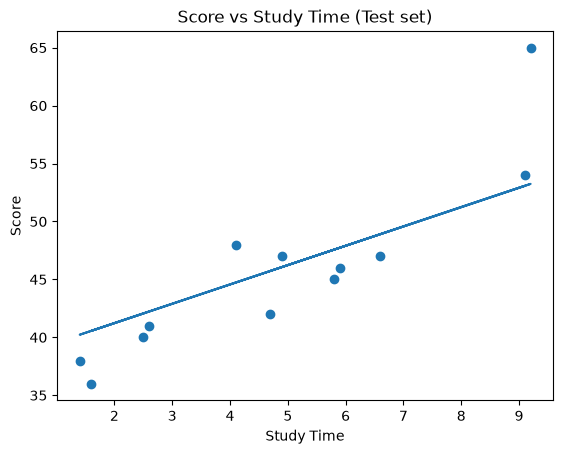

In [10]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test))

plt.title('Score vs Study Time (Test set)')
plt.xlabel('Study Time')
plt.ylabel('Score')

plt.show()